In [1]:
import pandas as pd

df = pd.read_csv('./diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv')

In [2]:
df.shape

(101766, 50)

In [3]:
question_counts = (df == '?').sum()
question_counts = question_counts[question_counts > 0].sort_values(ascending=False)

print(question_counts)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [4]:
# High number missing or N/A values
df.drop(["weight","medical_specialty", "payer_code"], axis=1, inplace=True)

# Useless information
df.drop(["encounter_id", "patient_nbr"], axis=1, inplace=True)

# Maybe drop:
# "max_glu_serum", "A1Cresult"
# "race", "gender"

df = df[df["diag_1"] !='?']
df = df[df["diag_2"] !='?']
df = df[df["diag_3"] !='?']

# Replace '?' with NaN
df = df.replace('?', pd.NA)

df.shape

(100244, 45)

In [5]:
print(df.isna().sum())

race                         2191
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               94981
A1Cresult                   83645
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone 

In [6]:
print(df["max_glu_serum"].unique())

[nan '>300' 'Norm' '>200']


In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

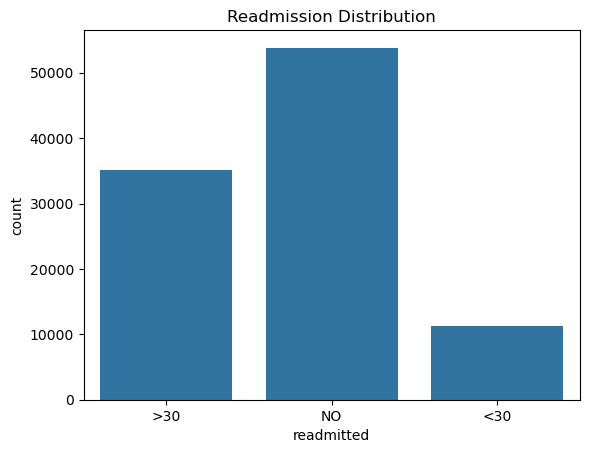

In [8]:
plt.figure()
sns.countplot(x='readmitted', data=df)
plt.title("Readmission Distribution")
plt.show()

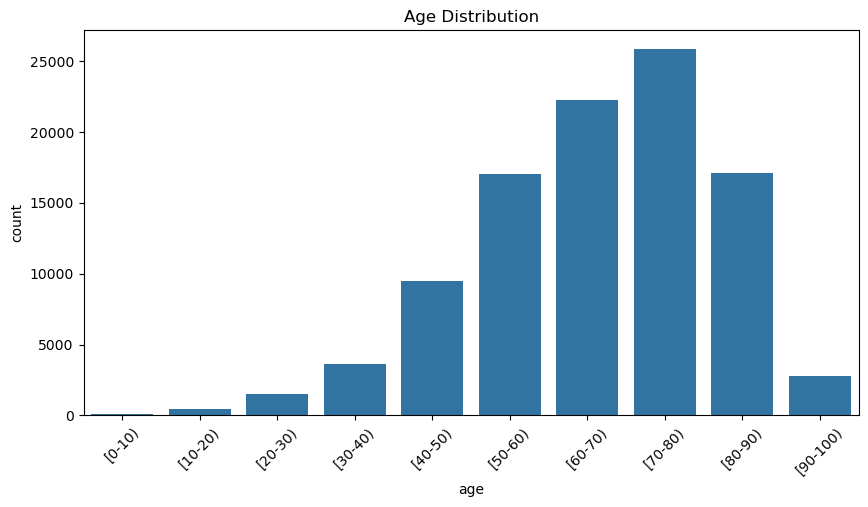

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', data=df, order=sorted(df['age'].dropna().unique()))
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

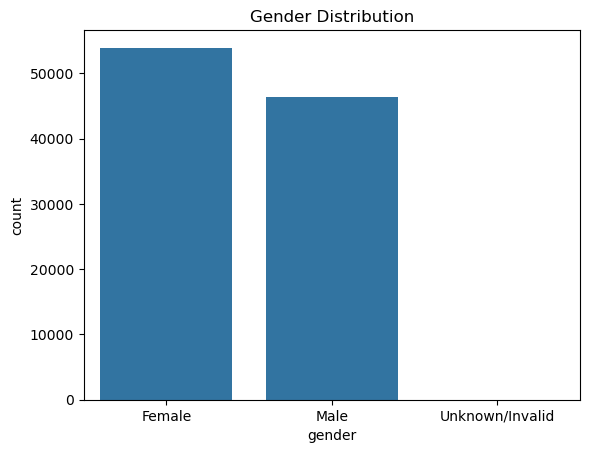

In [10]:
plt.figure()
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

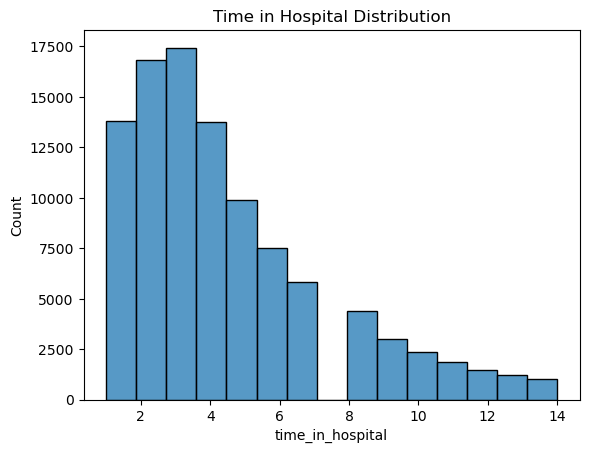

In [11]:
plt.figure()
sns.histplot(df['time_in_hospital'], bins=15)
plt.title("Time in Hospital Distribution")
plt.show()

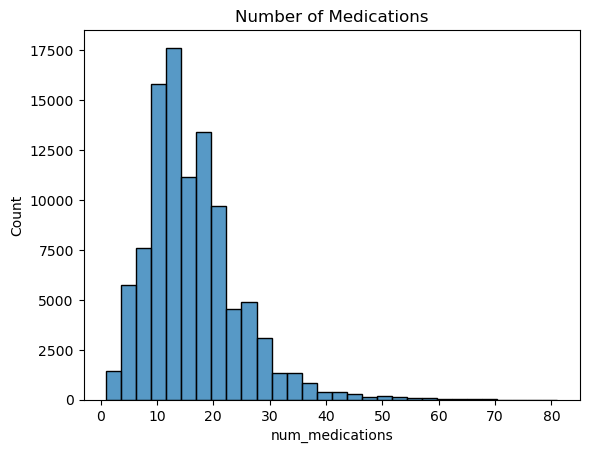

In [12]:
plt.figure()
sns.histplot(df['num_medications'], bins=30)
plt.title("Number of Medications")
plt.show()

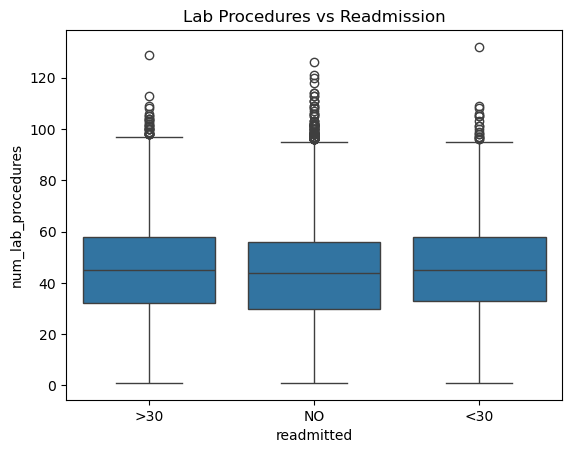

In [13]:
plt.figure()
sns.boxplot(x='readmitted', y='num_lab_procedures', data=df)
plt.title("Lab Procedures vs Readmission")
plt.show()

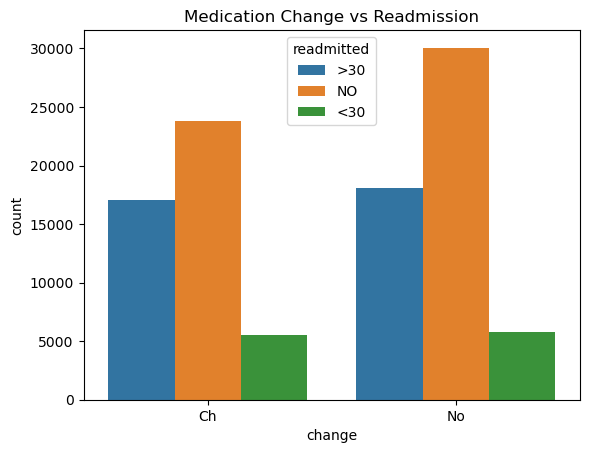

In [14]:
plt.figure()
sns.countplot(x='change', hue='readmitted', data=df)
plt.title("Medication Change vs Readmission")
plt.show()

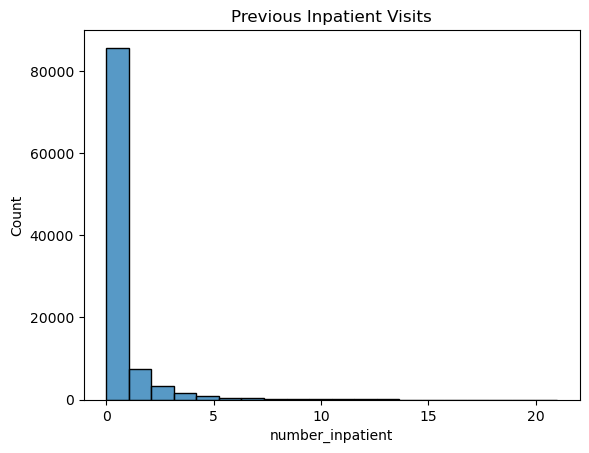

In [15]:
plt.figure()
sns.histplot(df['number_inpatient'], bins=20)
plt.title("Previous Inpatient Visits")
plt.show()

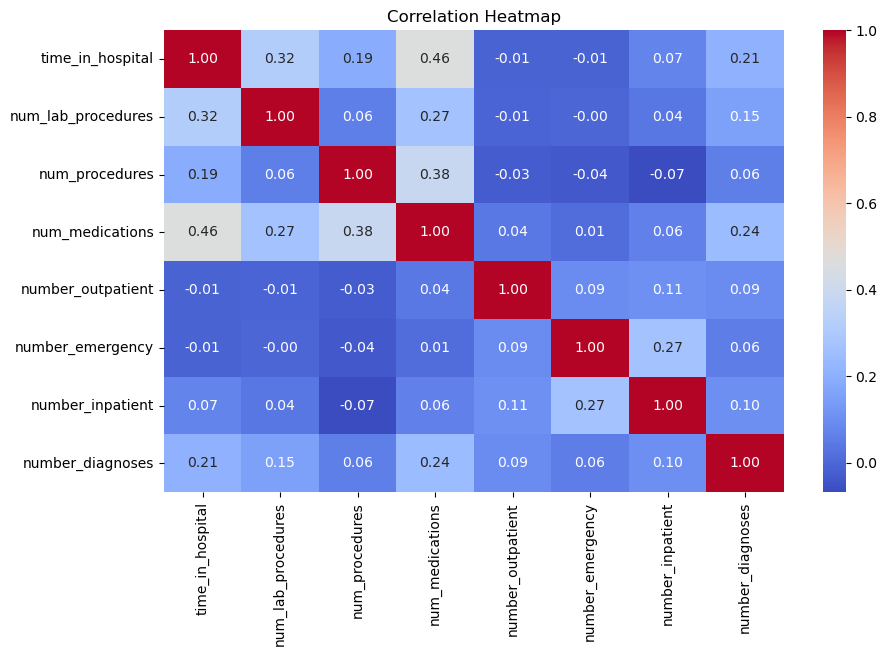

In [16]:
numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient',
    'number_emergency', 'number_inpatient',
    'number_diagnoses'
]

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

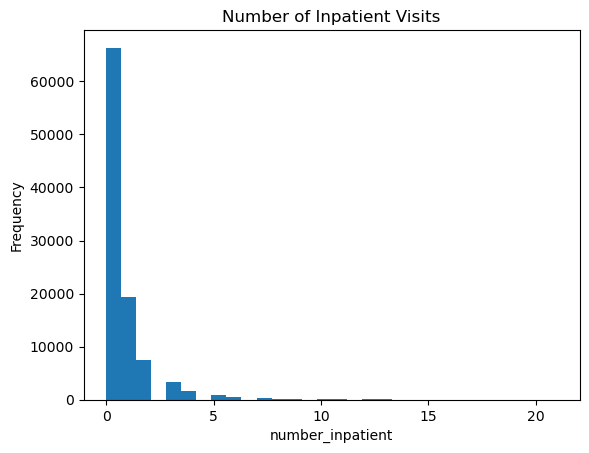

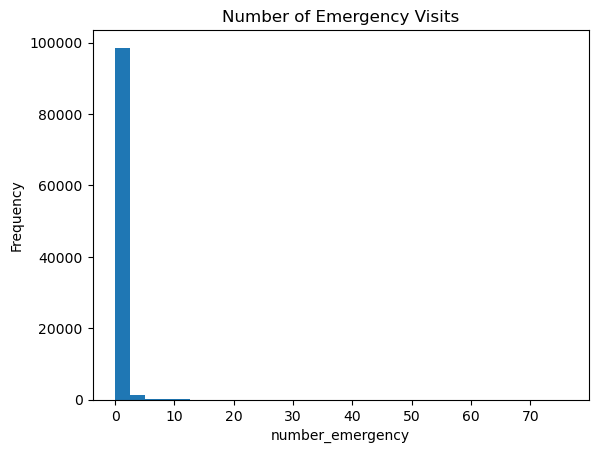

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["number_inpatient"].dropna(), bins=30)
plt.title("Number of Inpatient Visits")
plt.xlabel("number_inpatient")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df["number_emergency"].dropna(), bins=30)
plt.title("Number of Emergency Visits")
plt.xlabel("number_emergency")
plt.ylabel("Frequency")
plt.show()

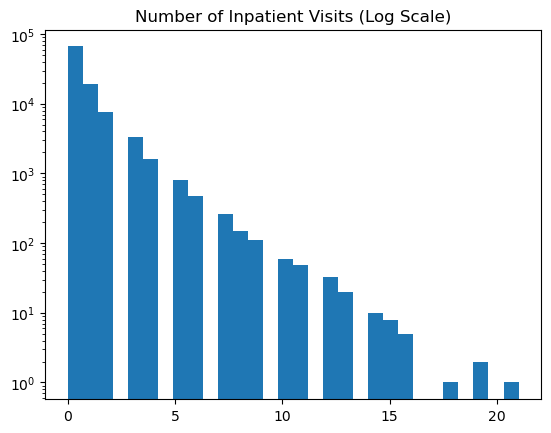

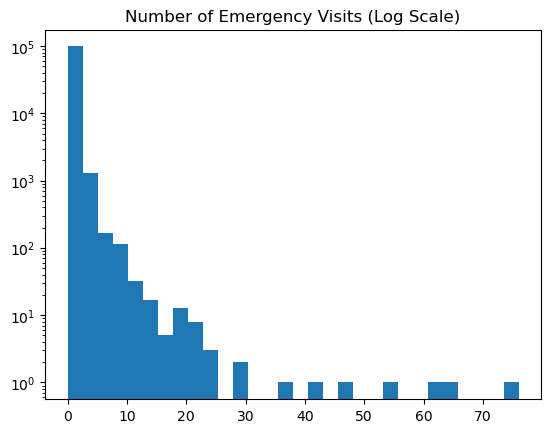

In [18]:
plt.figure()
plt.hist(df["number_inpatient"].dropna(), bins=30)
plt.yscale("log")
plt.title("Number of Inpatient Visits (Log Scale)")
plt.show()

plt.figure()
plt.hist(df["number_emergency"].dropna(), bins=30)
plt.yscale("log")
plt.title("Number of Emergency Visits (Log Scale)")
plt.show()

In [21]:
from process import clean_data
from model import train_knn, train_logistic, train_nn, train_rf
from sklearn.preprocessing import StandardScaler

import numpy as np

# df["number_inpatient_log"] = np.log1p(df["number_inpatient"])
# df["number_emergency_log"] = np.log1p(df["number_emergency"])

# # Before
# plt.figure()
# plt.hist(df["number_inpatient"], bins=30)
# plt.title("Original Inpatient")
# plt.show()

# # After
# plt.figure()
# plt.hist(df["number_inpatient_log"], bins=30)
# plt.title("Log Transformed Inpatient")
# plt.show()

# # df.drop(columns=["number_inpatient", "number_emergency"], inplace=True)

x_tr, x_val,x_te, y_tr, y_val, y_te= clean_data('./diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv')

#x_tr["number_inpatient_log"] = np.log1p(x_tr["number_inpatient"])
#x_tr["number_emergency_log"] = np.log1p(x_tr["number_emergency"])

#x_val["number_inpatient_log"] = np.log1p(x_val["number_inpatient"])
#x_val["number_emergency_log"] = np.log1p(x_val["number_emergency"])

#x_te["number_inpatient_log"] = np.log1p(x_te["number_inpatient"])
#x_te["number_emergency_log"] = np.log1p(x_te["number_emergency"])

scaler = StandardScaler()
x_tr_scaled = scaler.fit_transform(x_tr)
x_val_scaled = scaler.transform(x_val)
x_te_scaled = scaler.transform(x_te)

train_knn(x_tr_scaled, y_tr, x_val_scaled, y_val)
train_logistic(x_tr_scaled, y_tr, x_val_scaled, y_val)
train_nn(x_tr_scaled, y_tr, x_val_scaled, y_val)
train_rf(x_tr, y_tr, x_val, y_val)  

K-NN Accuracy K=3: 0.8635
K-NN Accuracy K=5: 0.8778
K-NN Accuracy K=7: 0.8841
K-NN Accuracy K=11: 0.8886
K-NN Accuracy K=15: 0.8882

--- K-Nearest Neighbors Results ---
Accuracy: 0.8886
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18094
           1       0.44      0.01      0.03      2259

    accuracy                           0.89     20353
   macro avg       0.66      0.51      0.48     20353
weighted avg       0.84      0.89      0.84     20353

Model saved to knn_model.pkl

--- Logistic Regression Results ---
Accuracy: 0.6487
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     18094
           1       0.18      0.59      0.27      2259

    accuracy                           0.65     20353
   macro avg       0.55      0.62      0.52     20353
weighted avg       0.84      0.65      0.71     20353

Model saved to logistic_reg_model.pkl

--- Neural Network Results ---
Accurac

In [23]:
train_knn(x_tr_scaled, y_tr, x_val_scaled, y_val)
train_logistic(x_tr_scaled, y_tr, x_val_scaled, y_val)
train_nn(x_tr_scaled, y_tr, x_val_scaled, y_val)
train_rf(x_tr, y_tr, x_val, y_val)

K-NN Accuracy K=3: 0.8635
K-NN Accuracy K=5: 0.8778
K-NN Accuracy K=7: 0.8841
K-NN Accuracy K=11: 0.8886
K-NN Accuracy K=15: 0.8882

--- K-Nearest Neighbors Results ---
Accuracy: 0.8886
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18094
           1       0.44      0.01      0.03      2259

    accuracy                           0.89     20353
   macro avg       0.66      0.51      0.48     20353
weighted avg       0.84      0.89      0.84     20353

Model saved to knn_model.pkl

--- Logistic Regression Results ---
Accuracy: 0.6487
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     18094
           1       0.18      0.59      0.27      2259

    accuracy                           0.65     20353
   macro avg       0.55      0.62      0.52     20353
weighted avg       0.84      0.65      0.71     20353

Model saved to logistic_reg_model.pkl

--- Neural Network Results ---
Accurac